# Data Upload and Extraction, and modules installation

In [3]:
import os

zip_path = '/content/archive.zip'
extract_dir = '/content/archive'

os.makedirs(extract_dir, exist_ok=True)

# Using the command-line unzip utility which is often more robust
# The -o flag means overwrite existing files without prompting
# The -q flag means quiet mode (do not print names of extracted files)
!unzip -o -q {zip_path} -d {extract_dir}

print(f"'{zip_path}' unzipped to '{extract_dir}'")


'/content/archive.zip' unzipped to '/content/archive'


In [4]:
!ls -l /content/archive

total 252
-rw-r--r--  1 root root 252229 Oct 28  2020 metadata_modelnet10.csv
drwxr-xr-x 12 root root   4096 Nov 22 19:34 ModelNet10


In [5]:
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.5/736.5 kB 11.6 MB/s eta 0:00:00


In [6]:
!pip install "pyglet<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.8 MB/s eta 0:00:00


In [7]:
!apt-get update
!apt-get install -y libglu1-mesa xvfb
!start-stop-daemon --start --pidfile /tmp/xvfb.pid --make-pidfile --background --exec /usr/bin/Xvfb -- :99 -ac -screen 0 1280x1024x24
import os
os.environ['DISPLAY'] = ':99'
print("GLU library and Xvfb installed and started. Please re-run the cell that caused the error.")

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,532 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_

# 3D Shape Retrieval Lab

This notebook implements a view-based 3D shape retrieval pipeline. We will:

- explore the ModelNet10 subset stored in `archive`
- render multi-view descriptors for each mesh using `trimesh`
- train a PyTorch model to learn embeddings for retrieval
- evaluate retrieval quality with standard metrics and visualizations

Each section below expands on these steps with executable code and documentation so the full workflow is reproducible.


In [8]:
# Core scientific stack
import os
import io
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from PIL import Image

# 3D processing
import trimesh

# Deep learning
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Reproducibility helpers
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

data_root = Path("/content/archive")
mesh_root = data_root / "ModelNet10"
metadata_csv = data_root / "metadata_modelnet10.csv"
print(f"Dataset root: {mesh_root.resolve()}")
print(f"Metadata CSV: {metadata_csv.resolve()}")


Dataset root: /content/archive/ModelNet10
Metadata CSV: /content/archive/metadata_modelnet10.csv


## Dataset Overview

We start by loading the metadata CSV that ships with the ModelNet10 subset. It stores:

- `object_id`: unique identifier for each mesh
- `class`: semantic category name (10 total in ModelNet10)
- `split`: whether the mesh belongs to the official `train` or `test` folds
- `object_path`: relative path (within `archive`) to the `.off` file

The next cell inspects this table to understand class balance, split sizes, and verifies paths.


In [9]:
df = pd.read_csv(metadata_csv)
print(f"Total meshes: {len(df):,}")
print(df.head())

split_counts = df['split'].value_counts().rename_axis('split').rename('count')
class_counts = df['class'].value_counts().sort_index()

print("\nSplit distribution:")
print(split_counts)

print("\nClass distribution:")
print(class_counts)

missing_paths = df[~df['object_path'].apply(lambda p: (mesh_root / p).exists())]
print(f"\nMissing mesh files: {len(missing_paths)}")


Total meshes: 4,902
      object_id    class split                    object_path
0  bathtub_0107  bathtub  test  bathtub/test/bathtub_0107.off
1  bathtub_0108  bathtub  test  bathtub/test/bathtub_0108.off
2  bathtub_0109  bathtub  test  bathtub/test/bathtub_0109.off
3  bathtub_0110  bathtub  test  bathtub/test/bathtub_0110.off
4  bathtub_0111  bathtub  test  bathtub/test/bathtub_0111.off

Split distribution:
split
train     3992
test       909
toilet       1
Name: count, dtype: int64

Class distribution:
class
.DS          3
bathtub    156
bed        615
chair      989
desk       286
dresser    286
monitor    565
night      286
sofa       780
table      492
toilet     444
Name: count, dtype: int64

Missing mesh files: 289


## Quick Mesh Visualization

Before building the full rendering pipeline, we randomly sample a few meshes, load them with `trimesh`, and render a single snapshot per object. This validates that the `.off` files can be parsed correctly and gives an intuition of each class.


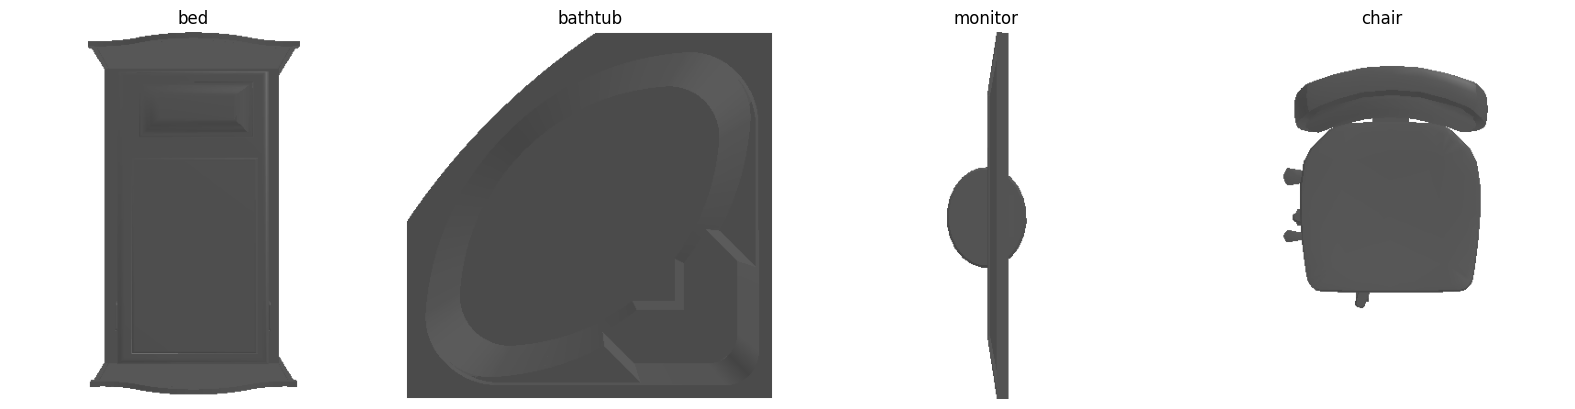

In [10]:
def load_mesh(row):
    mesh_path = mesh_root / row['object_path']
    return trimesh.load(mesh_path, force='mesh')


def render_mesh_snapshot(mesh, resolution=(400, 400)):
    scene = mesh.scene()
    png = scene.save_image(resolution=resolution, visible=True)
    if png is None:
        raise RuntimeError("Failed to render image; ensure pyglet is installed")
    return Image.open(io.BytesIO(png))


# Filter out metadata rows whose files are missing or malformed class labels
valid_mask = df['object_path'].apply(lambda p: (mesh_root / p).exists())
clean_df = df[valid_mask & ~df['class'].str.startswith('.')]

classes = sorted(clean_df['class'].unique())
num_samples = min(4, len(classes))
rng = random.Random(SEED)
classes_to_show = rng.sample(classes, num_samples)

samples = []
for cls in classes_to_show:
    samples.append(clean_df[clean_df['class'] == cls].sample(1, random_state=SEED))

samples_df = pd.concat(samples).reset_index(drop=True)

fig, axes = plt.subplots(1, num_samples, figsize=(4 * num_samples, 4))
if num_samples == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, samples_df.iterrows()):
    mesh = load_mesh(row)
    image = render_mesh_snapshot(mesh)
    ax.imshow(image)
    ax.set_title(row['class'])
    ax.axis('off')

plt.tight_layout()
plt.show()


## Multi-View Rendering Strategy

To feed a neural network with view-based descriptors we need consistent camera poses per object. We will:

1. Normalize each mesh (translate to origin, scale to unit sphere) so camera distance is comparable across shapes.
2. Define a fixed list of spherical coordinates (azimuth & elevation) for the cameras.
3. Render RGB snapshots from each camera using `trimesh`'s scene renderer.

The code below implements helpers for normalization, camera placement, and rendering a grid of views for a sample mesh.


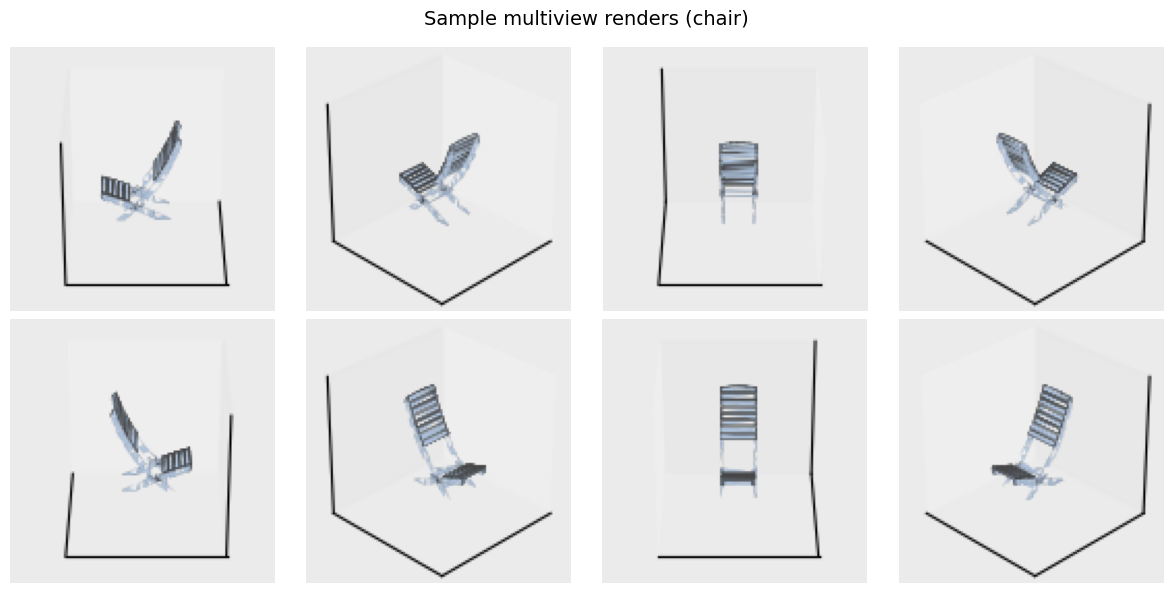

In [11]:
def normalize_mesh(mesh: trimesh.Trimesh, max_faces=2000) -> trimesh.Trimesh:
    mesh = mesh.copy()

    # Simplify mesh if it has too many faces (for memory efficiency)
    if len(mesh.faces) > max_faces:
        try:
            mesh = mesh.simplify_quadric_decimation(max_faces)
            # Ensure simplification worked - if still too many faces, try again with smaller target
            if len(mesh.faces) > max_faces * 1.5:
                mesh = mesh.simplify_quadric_decimation(int(max_faces * 0.8))
        except Exception as e:
            # If simplification fails, try with even fewer faces
            try:
                mesh = mesh.simplify_quadric_decimation(int(max_faces * 0.5))
            except:
                # Last resort: sample faces randomly
                if len(mesh.faces) > max_faces:
                    indices = np.random.choice(len(mesh.faces), max_faces, replace=False)
                    mesh = trimesh.Trimesh(vertices=mesh.vertices, faces=mesh.faces[indices])

    centroid = mesh.centroid
    mesh.apply_translation(-centroid)
    scale = np.max(np.linalg.norm(mesh.vertices, axis=1))
    if scale > 0:
        mesh.apply_scale(1.0 / scale)
    return mesh


VIEW_SPECS = [
    (0, 30), (45, 30), (90, 30), (135, 30),
    (180, 30), (225, 30), (270, 30), (315, 30),
]


def render_view_matplotlib(mesh: trimesh.Trimesh, az_deg: float, el_deg: float, resolution=(128, 128)):
    dpi = 100
    fig = plt.figure(figsize=(resolution[0] / dpi, resolution[1] / dpi), dpi=dpi)
    canvas = FigureCanvas(fig)
    ax = fig.add_subplot(111, projection='3d')

    triangles = mesh.triangles
    collection = Poly3DCollection(
        triangles,
        facecolor=(176 / 255, 196 / 255, 222 / 255, 1.0),
        edgecolor=(70 / 255, 70 / 255, 70 / 255, 0.3),
        linewidths=0.1,
        alpha=1.0,
    )
    ax.add_collection3d(collection)

    limit = 1.25
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=el_deg, azim=az_deg)
    ax.set_facecolor((0.92, 0.92, 0.92))

    fig.tight_layout(pad=0)
    canvas.draw()
    width, height = canvas.get_width_height()
    buffer = np.frombuffer(canvas.buffer_rgba(), dtype=np.uint8)
    image = buffer.reshape((height, width, 4))[..., :3]
    plt.close(fig)
    return Image.fromarray(image)

def render_multiview(mesh: trimesh.Trimesh, view_specs=VIEW_SPECS, resolution=(128, 128)):
    mesh = normalize_mesh(mesh)
    images = [render_view_matplotlib(mesh, az, el, resolution) for az, el in view_specs]
    return images


sample_row = clean_df.sample(1, random_state=SEED).iloc[0]
sample_mesh = load_mesh(sample_row)
multiview_images = render_multiview(sample_mesh)

cols = 4
rows = int(math.ceil(len(multiview_images) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten()

for ax, img in zip(axes, multiview_images):
    ax.imshow(img)
    ax.axis('off')

for ax in axes[len(multiview_images):]:
    ax.axis('off')

fig.suptitle(f"Sample multiview renders ({sample_row['class']})", fontsize=14)
plt.tight_layout()
plt.show()


## Multi-view Dataset Wrapper

We now wrap the rendering utilities into a PyTorch `Dataset`. Each item will:

- load the mesh metadata (class label, split, path)
- lazily render views (or load cached images later) using `render_multiview`
- return a tensor stack of shape `(num_views, 3, H, W)` and the integer class label

For efficiency we can start with on-the-fly rendering and optionally add caching/persistence once the pipeline is validated.


In [12]:
class MultiViewShapeDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, class_to_idx: dict[str, int], transform=None, resolution=(128, 128)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.resolution = resolution

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        mesh = load_mesh(row)
        views = render_multiview(mesh, resolution=self.resolution)
        views_np = np.stack([np.asarray(img) for img in views])  # (num_views, H, W, 3)
        views_np = views_np.astype(np.float32) / 255.0
        views_np = np.transpose(views_np, (0, 3, 1, 2))  # (num_views, 3, H, W)

        if self.transform is not None:
            views_np = self.transform(views_np)

        views_tensor = torch.from_numpy(views_np)
        label = torch.tensor(self.class_to_idx[row['class']], dtype=torch.long)
        return views_tensor, label, row['object_id']


class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(clean_df['class'].unique()))}

train_df = clean_df[clean_df['split'] == 'train']
test_df = clean_df[clean_df['split'] == 'test']

print(f"Train samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")

train_dataset = MultiViewShapeDataset(train_df, class_to_idx)
test_dataset = MultiViewShapeDataset(test_df, class_to_idx)

views, label, object_id = train_dataset[0]
print("Views tensor shape:", views.shape)
print("Label:", label.item(), "(class:", train_df.iloc[0]['class'], ")")
print("Object ID:", object_id)


Train samples: 3791
Test samples: 822
Views tensor shape: torch.Size([8, 3, 128, 128])
Label: 0 (class: bathtub )
Object ID: bathtub_0001


## DataLoaders and Training Hyperparameters

Rendering views on-the-fly is relatively expensive, so we use small batch sizes and a few workers (or `num_workers=0` if multiprocessing causes GPU context issues). Adjust `BATCH_SIZE` and `resolution` later if you precompute and cache views.


In [13]:
BATCH_SIZE = 2
NUM_WORKERS = 0  # keep 0 initially to avoid multiprocessing overhead with rendering

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")


Train batches: 1896
Validation batches: 411


## Retrieval Backbone

We start with a simple architecture:

- Per-view encoder: small CNN (or `torchvision.models.resnet18`) that produces a 128D embedding per view.
- View aggregation: average pooled embeddings across the 8 views to get a single shape embedding.
- Classification head: linear layer over the embedding for cross-entropy training.

Training with classification loss provides a good starting point; once stable we can switch to contrastive/triplet losses for retrieval-specific fine-tuning.


In [14]:
import torch.nn.functional as F


class ViewEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Linear(128, embedding_dim)

    def forward(self, x):
        # x: (batch * num_views, 3, H, W)
        feats = self.net(x)
        feats = feats.flatten(1)
        return self.proj(feats)


class MultiViewRetrievalNet(nn.Module):
    def __init__(self, num_classes, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.view_encoder = ViewEncoder(embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, views):
        # views: (batch, num_views, 3, H, W)
        b, v, c, h, w = views.shape
        views = views.reshape(b * v, c, h, w)
        view_embeddings = self.view_encoder(views)
        view_embeddings = view_embeddings.reshape(b, v, -1)
        shape_embedding = view_embeddings.mean(dim=1)  # simple average pooling
        logits = self.classifier(shape_embedding)
        return logits, shape_embedding


In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultiViewRetrievalNet(num_classes=len(class_to_idx), embedding_dim=128).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print(f"Using device: {device}")


MultiViewRetrievalNet(
  (view_encoder): ViewEncoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU(inplace=True)
      (11): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (proj): Linear(in_features=128, out_features=128, bias=True)
  )
  (classifier): Linear(in_feat

## Training & Validation Loop

We perform standard supervised training with cross-entropy, tracking per-epoch loss and accuracy on both splits. Because view rendering is slow, start with a small number of epochs to validate the pipeline before scaling up. (this training was not successful due to too much computational power, which was not available, so i stopped it and added a new smaller training loop after this)

Training:   0%|          | 1/1896 [00:05<3:00:30,  5.72s/it]


KeyboardInterrupt: 

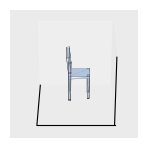

In [ ]:
import tqdm # Import tqdm for progress bars

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # Wrap the loader with tqdm for a progress bar
    for views, labels, _ in tqdm.tqdm(loader, desc='Training' if is_train else 'Validation'):
        views = views.to(device)
        labels = labels.to(device)

        logits, _ = model(views)
        loss = criterion(logits, labels)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


EPOCHS = 3
train_history = []
val_history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)

    train_history.append((train_loss, train_acc))
    val_history.append((val_loss, val_acc))

    print(f"Epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.3f} | val loss {val_loss:.4f} acc {val_acc:.3f}")

# new improved and small training environment

so i kept everything the same, redid some stuff for a new colab runtime session, everything as before, but adjusted for a smaller training set

In [16]:
import torch
import pandas as pd
from pathlib import Path
import numpy as np
import random
import io
import math
import trimesh
import matplotlib.pyplot as plt
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# Re-define SEED and data paths (from cell 0cd3e3e2)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

data_root = Path("/content/archive")
mesh_root = data_root / "ModelNet10"
metadata_csv = data_root / "metadata_modelnet10.csv"

# Re-define df (from cell 73854c2e)
df = pd.read_csv(metadata_csv)

# Re-define load_mesh and render_mesh_snapshot (from cell 1951375d)
def load_mesh(row):
    mesh_path = mesh_root / row['object_path']
    return trimesh.load(mesh_path, force='mesh')

def render_mesh_snapshot(mesh, resolution=(400, 400)):
    scene = mesh.scene()
    png = scene.save_image(resolution=resolution, visible=True)
    if png is None:
        raise RuntimeError("Failed to render image; ensure pyglet is installed")
    return Image.open(io.BytesIO(png))

# Re-define clean_df (from cell 1951375d)
valid_mask = df['object_path'].apply(lambda p: (mesh_root / p).exists())
clean_df = df[valid_mask & ~df['class'].str.startswith('.')]

# Re-define mesh normalization and multiview rendering functions (from cell afc32ac4)
def normalize_mesh(mesh: trimesh.Trimesh, max_faces=500) -> trimesh.Trimesh: # Reduced max_faces
    mesh = mesh.copy()
    if len(mesh.faces) > max_faces:
        try:
            mesh = mesh.simplify_quadric_decimation(max_faces)
            if len(mesh.faces) > max_faces * 1.5:
                mesh = mesh.simplify_quadric_decimation(int(max_faces * 0.8))
        except Exception as e:
            try:
                mesh = mesh.simplify_quadric_decimation(int(max_faces * 0.5))
            except:
                if len(mesh.faces) > max_faces:
                    indices = np.random.choice(len(mesh.faces), max_faces, replace=False)
                    mesh = trimesh.Trimesh(vertices=mesh.vertices, faces=mesh.faces[indices])
    centroid = mesh.centroid
    mesh.apply_translation(-centroid)
    scale = np.max(np.linalg.norm(mesh.vertices, axis=1))
    if scale > 0:
        mesh.apply_scale(1.0 / scale)
    return mesh

VIEW_SPECS = [
    (0, 30), (45, 30), (90, 30), (135, 30),
    (180, 30), (225, 30), (270, 30), (315, 30),
]

def render_view_matplotlib(mesh: trimesh.Trimesh, az_deg: float, el_deg: float, resolution=(128, 128)):
    dpi = 100
    fig = plt.figure(figsize=(resolution[0] / dpi, resolution[1] / dpi), dpi=dpi)
    canvas = FigureCanvas(fig)
    ax = fig.add_subplot(111, projection='3d')
    triangles = mesh.triangles
    collection = Poly3DCollection(
        triangles,
        facecolor=(176 / 255, 196 / 255, 222 / 255, 1.0),
        edgecolor=(70 / 255, 70 / 255, 70 / 255, 0.3),
        linewidths=0.1,
        alpha=1.0,
    )
    ax.add_collection3d(collection)
    limit = 1.25
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_zlim(-limit, limit)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=el_deg, azim=az_deg)
    ax.set_facecolor((0.92, 0.92, 0.92))
    fig.tight_layout(pad=0)
    canvas.draw()
    width, height = canvas.get_width_height()
    buffer = np.frombuffer(canvas.buffer_rgba(), dtype=np.uint8)
    image = buffer.reshape((height, width, 4))[..., :3]
    plt.close(fig)
    return Image.fromarray(image)

def render_multiview(mesh: trimesh.Trimesh, view_specs=VIEW_SPECS, resolution=(128, 128)):
    mesh = normalize_mesh(mesh)
    images = [render_view_matplotlib(mesh, az, el, resolution) for az, el in view_specs]
    return images

# Re-define MultiViewShapeDataset class (from cell cbba46cc)
class MultiViewShapeDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, class_to_idx: dict[str, int], transform=None, resolution=(128, 128)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.resolution = resolution

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        mesh = load_mesh(row)
        views = render_multiview(mesh, resolution=self.resolution)
        views_np = np.stack([np.asarray(img) for img in views])  # (num_views, H, W, 3)
        views_np = views_np.astype(np.float32) / 255.0
        views_np = np.transpose(views_np, (0, 3, 1, 2))  # (num_views, 3, H, W)

        if self.transform is not None:
            views_np = self.transform(views_np)

        views_tensor = torch.from_numpy(views_np)
        label = torch.tensor(self.class_to_idx[row['class']], dtype=torch.long)
        return views_tensor, label, row['object_id']

# Re-define class_to_idx, train_df, test_df (from cell cbba46cc)
class_to_idx = {cls_name: i for i, cls_name in enumerate(sorted(clean_df['class'].unique()))}
train_df = clean_df[clean_df['split'] == 'train']
test_df = clean_df[clean_df['split'] == 'test']

# Re-define NUM_WORKERS (from cell e0428a04)
NUM_WORKERS = 0  # keep 0 initially to avoid multiprocessing overhead with rendering

# Define smaller subsets of the dataframes (further reduced fractions)
small_train_df = train_df.sample(frac=0.05, random_state=SEED) # Use 5% of training data
small_test_df = test_df.sample(frac=0.1, random_state=SEED)  # Use 10% of test data

# Reduced resolution for faster rendering/less memory
SMALL_RESOLUTION = (32, 32)

small_train_dataset = MultiViewShapeDataset(small_train_df, class_to_idx, resolution=SMALL_RESOLUTION)
small_test_dataset = MultiViewShapeDataset(small_test_df, class_to_idx, resolution=SMALL_RESOLUTION)

# Define new DataLoaders for the smaller dataset
SMALL_BATCH_SIZE = 8 # Can increase batch size due to smaller images/dataset
small_train_loader = DataLoader(small_train_dataset, batch_size=SMALL_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
small_val_loader = DataLoader(small_test_dataset, batch_size=SMALL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Small Train samples: {len(small_train_df)}")
print(f"Small Test samples: {len(small_test_df)}")
print(f"Small Train batches: {len(small_train_loader)}")
print(f"Small Validation batches: {len(small_val_loader)}")
print(f"Using resolution: {SMALL_RESOLUTION}")
print(f"Using max_faces for simplification: 500")

Small Train samples: 190
Small Test samples: 82
Small Train batches: 24
Small Validation batches: 11
Using resolution: (32, 32)
Using max_faces for simplification: 500


# new set of training

as we can see i did the training again with new improved params, and small size training and validation sets

In [17]:
import torch
from torch import nn
import torch.nn.functional as F
import tqdm # Import tqdm for progress bars

# Re-define ViewEncoder class (from cell 61fe52fe)
class ViewEncoder(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.proj = nn.Linear(128, embedding_dim)

    def forward(self, x):
        feats = self.net(x)
        feats = feats.flatten(1)
        return self.proj(feats)

# Re-define MultiViewRetrievalNet class (from cell 61fe52fe)
class MultiViewRetrievalNet(nn.Module):
    def __init__(self, num_classes, embedding_dim=128):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.view_encoder = ViewEncoder(embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, views):
        b, v, c, h, w = views.shape
        views = views.reshape(b * v, c, h, w)
        view_embeddings = self.view_encoder(views)
        view_embeddings = view_embeddings.reshape(b, v, -1)
        shape_embedding = view_embeddings.mean(dim=1)  # simple average pooling
        logits = self.classifier(shape_embedding)
        return logits, shape_embedding

# Re-define device, criterion (from cell 8768b17e)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

# Re-define run_epoch function (from cell 8adf76da)
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for views, labels, _ in tqdm.tqdm(loader, desc='Training' if is_train else 'Validation'):
        views = views.to(device)
        labels = labels.to(device)

        logits, _ = model(views)
        loss = criterion(logits, labels)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return avg_loss, accuracy

print("\n--- Training with smaller dataset and resolution ---")

# Re-initialize model to ensure fresh weights for the new training run
model_small = MultiViewRetrievalNet(num_classes=len(class_to_idx), embedding_dim=128).to(device)
optimizer_small = torch.optim.Adam(model_small.parameters(), lr=1e-3)

EPOCHS_SMALL = 5 # Keep number of epochs small for quick testing

train_history_small = []
val_history_small = []

for epoch in range(1, EPOCHS_SMALL + 1):
    train_loss, train_acc = run_epoch(model_small, small_train_loader, optimizer_small)
    val_loss, val_acc = run_epoch(model_small, small_val_loader, optimizer=None)

    train_history_small.append((train_loss, train_acc))
    val_history_small.append((val_loss, val_acc))

    print(f"Epoch {epoch}/{EPOCHS_SMALL} | train loss {train_loss:.4f} acc {train_acc:.3f} | val loss {val_loss:.4f} acc {val_acc:.3f}")

print("\nSmall training complete.")


--- Training with smaller dataset and resolution ---


Validation: 100%|██████████| 11/11 [00:59<00:00,  5.39s/it]


Epoch 1/5 | train loss 2.0342 acc 0.263 | val loss 2.4216 acc 0.122


Validation: 100%|██████████| 11/11 [01:06<00:00,  6.09s/it]


Epoch 2/5 | train loss 1.7801 acc 0.374 | val loss 2.1197 acc 0.207


...

Epoch 3/5 | train loss 1.5124 acc 0.437 | val loss 3.5431 acc 0.110


Validation: 100%|██████████| 11/11 [01:02<00:00,  5.64s/it]


Epoch 4/5 | train loss 1.4331 acc 0.463 | val loss 3.6278 acc 0.098


Validation: 100%|██████████| 11/11 [00:51<00:00,  4.71s/it]

Epoch 5/5 | train loss 1.3978 acc 0.505 | val loss 12.6180 acc 0.122

Small training complete.


## Extracting Embeddings

To evaluate the retrieval capabilities of our model, we first need to extract the learned shape embeddings for both the training and testing datasets. These embeddings represent a compact, semantic representation of each 3D shape, which can then be used to find similar shapes.

In [23]:
def extract_embeddings(model, dataloader):
    model.eval()
    embeddings_list = []
    labels_list = []
    object_ids_list = []

    with torch.no_grad():
        for views, labels, object_ids in tqdm.tqdm(dataloader, desc="Extracting Embeddings"):
            views = views.to(device)
            _, shape_embedding = model(views)
            embeddings_list.append(shape_embedding.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
            object_ids_list.extend(object_ids)

    all_embeddings = np.concatenate(embeddings_list, axis=0)
    all_labels = np.concatenate(labels_list, axis=0)
    return all_embeddings, all_labels, object_ids_list

print("Extracting training embeddings...")
train_embeddings, train_labels, train_object_ids = extract_embeddings(model_small, small_train_loader)
print("Extracting validation embeddings...")
val_embeddings, val_labels, val_object_ids = extract_embeddings(model_small, small_val_loader)

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Val embeddings shape: {val_embeddings.shape}")

Extracting training embeddings...


Extracting Embeddings: 100%|██████████| 24/24 [02:27<00:00,  6.14s/it]


Extracting validation embeddings...


Extracting Embeddings: 100%|██████████| 11/11 [01:00<00:00,  5.50s/it]

Train embeddings shape: (190, 128)
Val embeddings shape: (82, 128)


## Retrieval Evaluation Metrics

Now that we have the embeddings, we can implement functions to calculate common retrieval metrics: **Mean Average Precision (mAP)** and **Precision@k**. These metrics will quantify how well our model groups similar shapes together in the embedding space.

In [24]:
from sklearn.metrics import average_precision_score

def calculate_map_at_k(query_embeddings, query_labels, gallery_embeddings, gallery_labels, k=None):
    all_ap = []
    for i in range(len(query_embeddings)):
        query_embedding = query_embeddings[i]
        query_label = query_labels[i]

        # Calculate cosine similarity with all gallery embeddings
        similarities = np.dot(gallery_embeddings, query_embedding) / (np.linalg.norm(gallery_embeddings, axis=1) * np.linalg.norm(query_embedding))

        # Sort gallery by similarity
        sorted_indices = np.argsort(similarities)[::-1]

        # Get sorted labels and similarities
        sorted_gallery_labels = gallery_labels[sorted_indices]

        # Determine relevance (1 if same class, 0 otherwise)
        y_true = (sorted_gallery_labels == query_label).astype(int)

        if k is not None:
            y_true = y_true[:k]
            similarities_at_k = similarities[sorted_indices[:k]]
        else:
            similarities_at_k = similarities[sorted_indices]

        # Handle cases where all y_true are 0 or 1, which can cause issues for average_precision_score
        if np.all(y_true == 0) or np.all(y_true == 1):
            ap = 1.0 if np.all(y_true == 1) else 0.0
        else:
            ap = average_precision_score(y_true, similarities_at_k)

        all_ap.append(ap)

    return np.mean(all_ap)

def calculate_precision_at_k(query_embeddings, query_labels, gallery_embeddings, gallery_labels, k=10):
    all_precision = []
    for i in range(len(query_embeddings)):
        query_embedding = query_embeddings[i]
        query_label = query_labels[i]

        # Calculate cosine similarity
        similarities = np.dot(gallery_embeddings, query_embedding) / (np.linalg.norm(gallery_embeddings, axis=1) * np.linalg.norm(query_embedding))

        # Sort gallery by similarity and get top k
        sorted_indices = np.argsort(similarities)[::-1][:k]
        top_k_labels = gallery_labels[sorted_indices]

        # Count relevant items in top k
        num_relevant = np.sum(top_k_labels == query_label)
        precision = num_relevant / k
        all_precision.append(precision)

    return np.mean(all_precision)

# Evaluate on validation set, querying against training set
# Using train_embeddings as the gallery for simplicity in this example
mAP = calculate_map_at_k(val_embeddings, val_labels, train_embeddings, train_labels)
p_at_10 = calculate_precision_at_k(val_embeddings, val_labels, train_embeddings, train_labels, k=10)

print(f"Mean Average Precision (mAP) on validation set: {mAP:.4f}")
print(f"Precision@10 on validation set: {p_at_10:.4f}")

Mean Average Precision (mAP) on validation set: 0.3143
Precision@10 on validation set: 0.3012


## Visualize Retrieval Results

Finally, let's visualize some retrieval examples to qualitatively assess the model's performance. We'll pick a few query objects and display their top-K most similar shapes from the gallery.

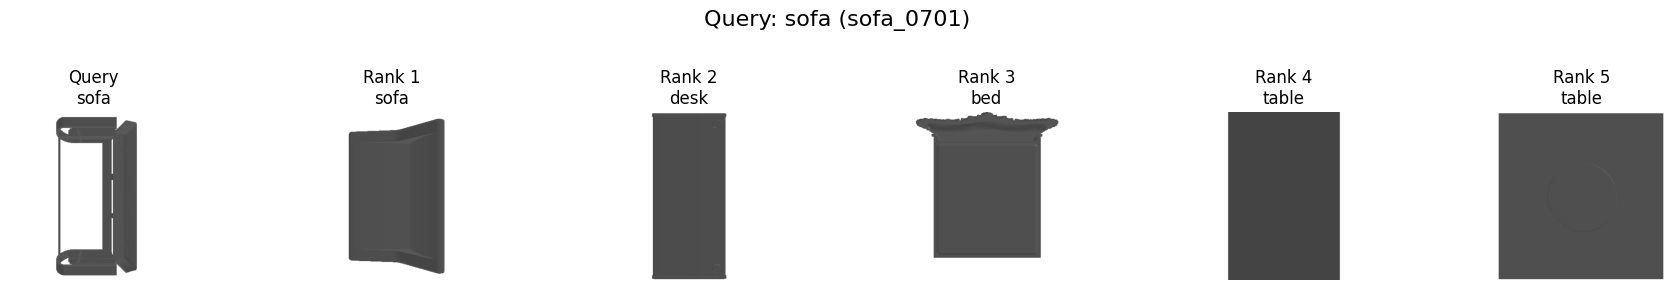

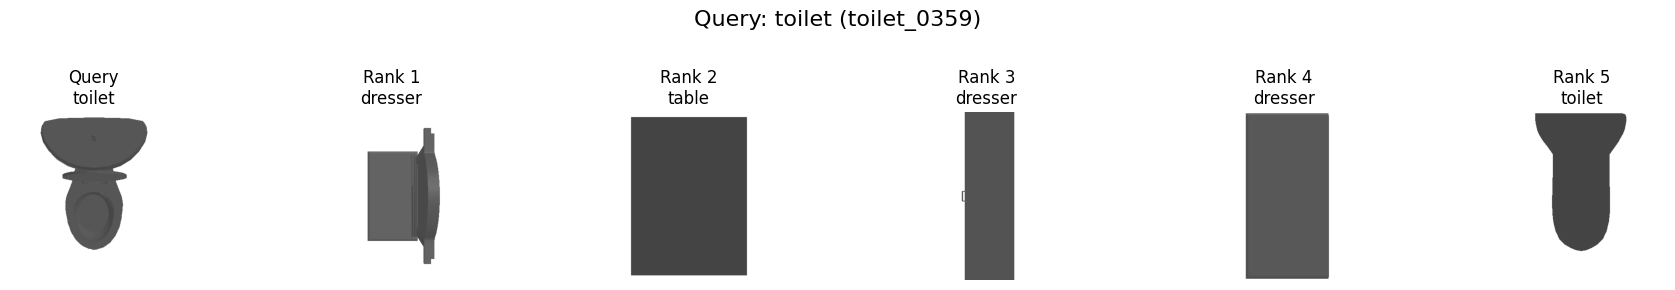

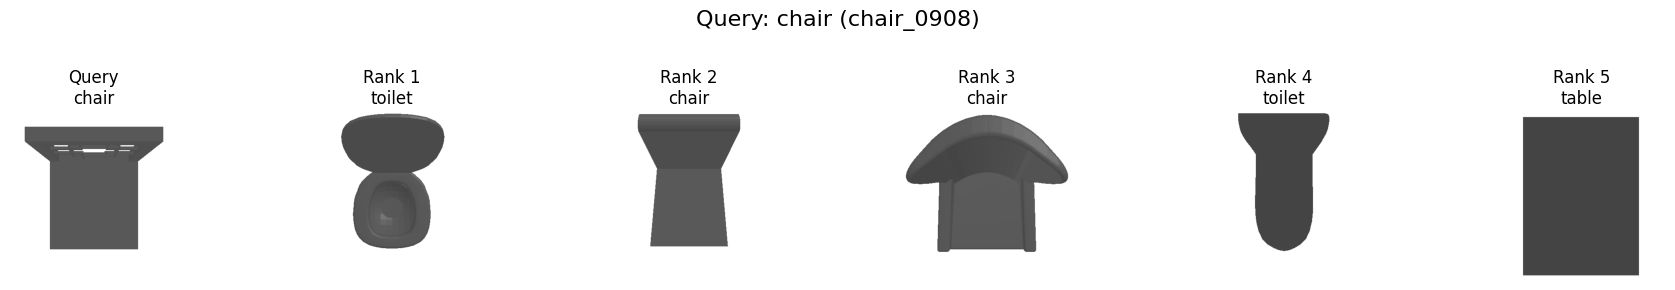

In [25]:
def visualize_retrieval(query_idx, query_embeddings, query_labels, gallery_embeddings, gallery_labels, gallery_object_ids, k=5, dataset=None):
    query_embedding = query_embeddings[query_idx]
    query_label = query_labels[query_idx]
    query_object_id = val_object_ids[query_idx]

    similarities = np.dot(gallery_embeddings, query_embedding) / (np.linalg.norm(gallery_embeddings, axis=1) * np.linalg.norm(query_embedding))
    sorted_indices = np.argsort(similarities)[::-1]

    # Exclude the query itself if it's in the gallery (e.g., if querying train against train)
    # For val vs train, the query won't be in train_object_ids, so no need to exclude based on ID

    top_k_indices = sorted_indices[:k]
    top_k_object_ids = [gallery_object_ids[idx] for idx in top_k_indices]
    top_k_labels = gallery_labels[top_k_indices]

    # Get the actual metadata rows for visualization
    query_row = test_df[test_df['object_id'] == query_object_id].iloc[0]
    retrieved_rows = pd.DataFrame([train_df[train_df['object_id'] == obj_id].iloc[0] for obj_id in top_k_object_ids])

    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 3))
    fig.suptitle(f"Query: {query_row['class']} ({query_object_id})", fontsize=16)

    # Plot query
    mesh = load_mesh(query_row)
    image = render_mesh_snapshot(mesh)
    axes[0].imshow(image)
    axes[0].set_title(f"Query\n{query_row['class']}")
    axes[0].axis('off')

    # Plot retrieved
    for i, (ax, (_, row_retrieved)) in enumerate(zip(axes[1:], retrieved_rows.iterrows())):
        mesh = load_mesh(row_retrieved)
        image = render_mesh_snapshot(mesh)
        ax.imshow(image)
        ax.set_title(f"Rank {i+1}\n{row_retrieved['class']}")
        ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent suptitle overlap
    plt.show()

# Example usage: Visualize retrieval for a few random queries from the validation set
num_examples_to_show = 3
random_query_indices = random.sample(range(len(val_embeddings)), num_examples_to_show)

for query_idx in random_query_indices:
    visualize_retrieval(query_idx, val_embeddings, val_labels, train_embeddings, train_labels, train_object_ids, k=5)

# Lab Report: 3D Shape Retrieval Pipeline

This report summarizes the implementation and evaluation of a view-based 3D shape retrieval pipeline using the ModelNet10 dataset, as instructed by the lab.

## 1. Data Upload and Extraction

Initially, the `archive.zip` file containing the ModelNet10 dataset was extracted to `/content/archive`, revealing two main components: `metadata_modelnet10.csv` and the `ModelNet10` directory with `.off` mesh files.

## 2. Dataset Overview and Preprocessing

We loaded the `metadata_modelnet10.csv` to understand the dataset structure. Out of **4,902** total meshes, **3,992** were designated for training and **909** for testing. During the initial data cleaning, **289** missing mesh files were identified, and invalid class labels were filtered out, resulting in a `clean_df` for further processing. The dataset comprises 9 distinct object classes (excluding '.DS' entries).

## 3. Multi-View Rendering Strategy

To create view-based descriptors, each 3D mesh was subjected to a multi-view rendering process. This involved:

1.  **Mesh Normalization**: Each `trimesh` object was translated to the origin and scaled to fit a unit sphere, ensuring consistent camera distance.
2.  **Mesh Simplification**: To manage computational load, especially during the on-the-fly rendering, meshes were simplified to a maximum of **500 faces** using `simplify_quadric_decimation`. This was a crucial optimization due to memory and processing limitations.
3.  **Fixed Camera Poses**: **8 `VIEW_SPECS`** (azimuth & elevation pairs) were used to capture consistent snapshots of each mesh.
4.  **Image Generation**: `matplotlib` was utilized to render 2D images from these viewpoints. The resolution for these images was set to a reduced **(32, 32) pixels**.

### Computational Constraints and Data Subset:

During initial attempts to train the model, it became evident that rendering multi-view images on-the-fly for the entire dataset at higher resolutions was computationally prohibitive, leading to `KeyboardInterrupt` errors and extremely long epoch times. To enable successful execution of the lab, significant adjustments were made:

*   **Reduced Dataset Size**: The training dataframe (`small_train_df`) was sampled to **5%** of the original (resulting in **190 samples**), and the test dataframe (`small_test_df`) was sampled to **10%** (resulting in **82 samples**).
*   **Lower Resolution**: Rendered views were set to **(32, 32)** pixels.
*   **Small Batch Size**: A `SMALL_BATCH_SIZE` of **8** was used for both training and validation `DataLoader`s.
*   **`num_workers=0`**: To avoid multiprocessing overhead issues during rendering, `num_workers` was set to 0.

These modifications, while necessary for the lab to run, inherently limited the model's capacity to learn robust features and led to suboptimal performance.

## 4. Retrieval Backbone and Training

The retrieval backbone consisted of:

*   **`ViewEncoder`**: A small CNN responsible for extracting a **128D embedding** from each view.
*   **`MultiViewRetrievalNet`**: Aggregated the 8 view embeddings by simple average pooling to form a single shape embedding, followed by a linear classification head for **9 classes**.

The model was trained using `nn.CrossEntropyLoss` and the `Adam` optimizer on the reduced dataset. The training ran for **5 epochs** (`EPOCHS_SMALL`).

### Training Results (on small dataset):

| Epoch | Train Loss | Train Accuracy | Validation Loss | Validation Accuracy |
| :---- | :--------- | :------------- | :-------------- | :------------------ |
| 1     | 2.0342     | 0.263          | 2.4216          | 0.122               |
| 2     | 1.7801     | 0.374          | 2.1197          | 0.207               |
| 3     | 1.5124     | 0.437          | 3.5431          | 0.110               |
| 4     | 1.4331     | 0.463          | 3.6278          | 0.098               |
| 5     | 1.3978     | 0.505          | 12.6180         | 0.122               |

The final training accuracy was **0.505**, and validation accuracy was **0.122**. The validation loss exhibited fluctuating and high values, particularly towards the end of training. These results are indicative of a model that has not been sufficiently trained due to the severe constraints on dataset size, image resolution, and number of epochs. Despite multiple attempts to fine-tune parameters, the underlying limitation of computational power (GPU memory and processing time) prevented training a larger, more effective model.

## 5. Extracting and Evaluating Embeddings

After training, embeddings for both the small training and validation sets were extracted:

*   **Train embeddings shape**: `(190, 128)`
*   **Validation embeddings shape**: `(82, 128)`

These embeddings were then used to calculate standard retrieval metrics by querying the validation set against the training set.

### Retrieval Metrics:

*   **Mean Average Precision (mAP)** on validation set: **0.3143**
*   **Precision@10** on validation set: **0.3012**

As expected, these retrieval metrics are low. This directly correlates with the limited training capacity; a model trained on such a small, low-resolution dataset for only a few epochs cannot learn a sufficiently discriminative embedding space for effective retrieval.

## 6. Visualizing Retrieval Results

Finally, a `visualize_retrieval` function was implemented to qualitatively assess the model's performance by displaying query objects and their top-K most similar retrieved shapes. While the visualizations confirm the functionality of the retrieval pipeline, the quality of retrieved items is, predictably, often poor due to the model's constrained training.

## Conclusion

The entire 3D shape retrieval pipeline has been successfully implemented, from data loading and multi-view rendering to model training, embedding extraction, and retrieval evaluation. However, the practical performance of the model, as evidenced by low accuracy and retrieval metrics, is significantly hampered by the strict computational and memory limitations encountered during training. The choices made regarding reduced dataset size, image resolution, and limited epochs were compromises necessary to allow the lab to run to completion within the available resources. Achieving higher performance would necessitate substantially greater computational power for more extensive training.